In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('adjust_ys3')

In [2]:
data = np.loadtxt('dRMStraj_nc_StateA.dat')

In [3]:
data.shape

(80001, 12)

In [4]:
# data = np.loadtxt('distance_mp.dat')

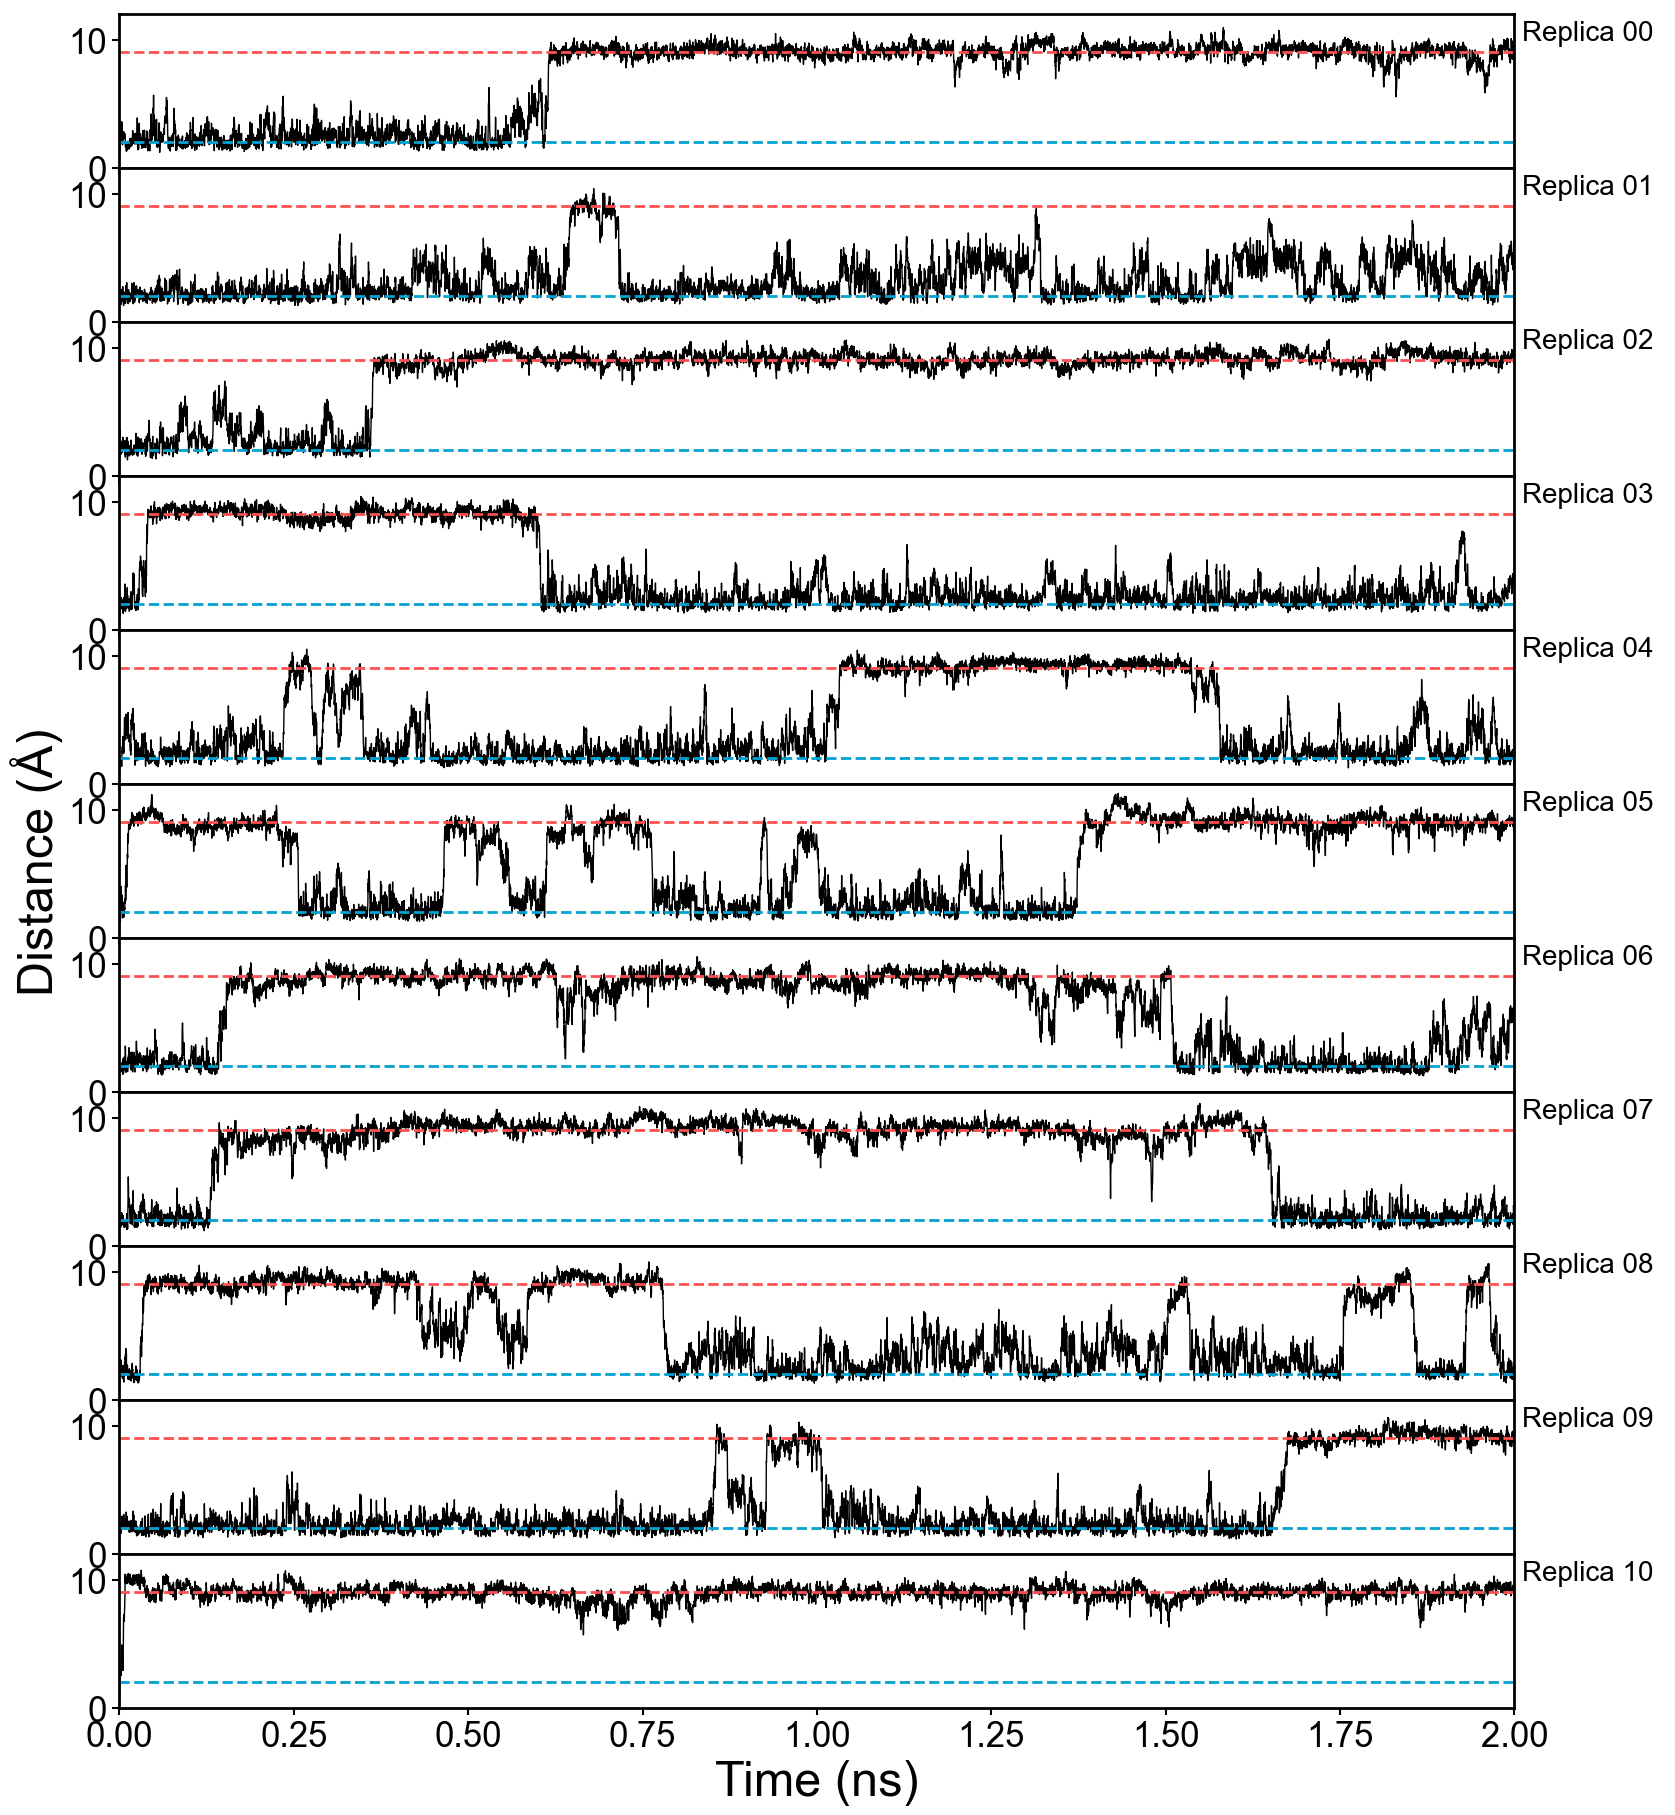

In [7]:
# ref_dist_closed = 34.2745
# ref_dist_open = 48.7876
colormap=[np.array([255,81,81])/255,np.array([0,162,210])/255]

# Assuming replica_state_indices is a 2D array with shape (n_replica, n_timesteps)
n_replica = data.shape[1] - 1  # Get number of states
skip = 10
dt = 250 * 0.02 /1000000
time = data[::skip,0] * dt# Time unit in us

# Create figure with vertically stacked subplots
fig, axes = plt.subplots(n_replica, 1, figsize=(18, 2*n_replica), sharex=True)
fig.subplots_adjust(hspace=0)

labels = [f'Replica {i:02d}' for i in range(n_replica)]
for i, ax in enumerate(axes):
    ax.plot(time, data[::skip, i+1], label=labels[i], color='black', lw=1)
    ax.legend(loc="upper right", bbox_to_anchor=(1.11, 1.05), fontsize=20, handlelength=0)
    ax.axhline(9, color=colormap[0], ls='dashed', lw=2)
    ax.axhline(2, color=colormap[1], ls='dashed', lw=2)

    # ax.set_yticks([35, 50]) 
    ax.set_ylim(0,12)
    # ax.tick_params(axis='y', labelsize=25) 
    

ax.set_xlim(0, 2)
axes[5].set_ylabel('Distance (Å)')
# Only add xlabel to the bottom plot
axes[-1].set_xlabel('Time (ns)')
plt.show()